# readDiag - Versão Gerd - Convencionais

Notebook para gerar resutados das análises do processo de assimilação pelo GSI no SMNA com os arquivos prepBUFR
elaborados por INPE e NCEP.


## Utilização da classe `read_diag`

### Bibliotecas necessárias

Para iniciar a utilização do `readDiag`, carregue primeiro as bibliotecas necessárias para a sua utilização:

* `gsidiag`: é a biblioteca que contém as classes `read_diag` e `plot_diag`;
* `pandas`: é a biblioteca que fornece as estruturas de dados tabulados utilizadas pelo `readDiag`;
* `matplotlib`: é a biblioteca a partir da qual são confeccionadas as figuras;
* `datetime`: é a biblioteca utilizada para manipular datas.

A instrução `%matplotlib inline` é um comando mágico do Jupyter e apenas ajusta o ambiente para que não seja necessário utilizar o comando `plt.show()` sempre que figuras forem mostradas dentro do notebook. Se você estiver utilizando o `readDiag` dentro de um script Python, esta diretiva pode ser suprimida e o comando `plt.show()` deve ser utilizado, a depender da situação.

In [ ]:
# Descomente a linha a seguir para utilizar este notebook no Google Colab
#!pip install readDiag

In [1]:
import gsidiag as gd

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from gsidiag.datasources import getVarInfo

import os

%matplotlib inline

/tmp/ipykernel_2559/1422729586.py:1: DeprecationWarning: You are importing the legacy package 'gsidiag'. This interface is deprecated and will be removed in a future major release. Please migrate to 'readDiag.open.open_diagnostic' and the DiagnosticAPI.
  import gsidiag as gd


In [2]:
# Para uso em máquina local (neste caso, o diretório remoto deverá ser montado localmente com o comando sshfs)
# Exemplo: 
# $ sshfs username@egeon.cptec.inpe.br:/pesq/share/das/dist/joao.gerd/EXP18/GSI/dataout /extra2/EGEON_EXP18_GSI_dataout
# ou
# $ sshfs username@itapemirim.cptec.inpe.br:/share/das/dist/joao.gerd/EXP18/GSI/dataout /extra2/EGEON_EXP18_GSI_dataout
# DIRdiag = '/extra2/EGEON_EXP18_GSI_dataout'

# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/prepbufr_amsua_INPE/')
# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/prepbufr_amsua_NCEP/')
# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/prepbufr_conv_NCEP/')
# dateIni = '2025082012' 
# dateFin = '2025082012'
# nHour = '6'

# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/IBIS/ATMS_AMSUA/gsi_dataout/SMNA_v3.0.0.t11889-atms-amsu/SMG/datainout/gsi/dataout/')
# dateIni = '2025050906' #'2025082012' 
# dateFin = '2025050906' #'2025082012'
# nHour = '6'

# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/prepINPE_press')
# # DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/prepNCEP_press')
# dateIni = '2025090412' 
# dateFin = '2025090412'
# nHour = '6'

# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/prepINPE/i79') # Eduardo
# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/prepINPE/DIMNT') # Sergio
# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/prepNCEP') # NCEP
# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/prepINPE/i80') # Eduardo
# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/2025090412prepbufrINPE_i84') # Eduardo
# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/2025090412prepINPE_i88') # Eduardo
# dateIni = '2025090412' 
# dateFin = '2025090412'
# nHour = '6'

#DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/2026021900satwndINPE_i90') # Eduardo
# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/2026021900satwndNCEP_i90')
# dateIni = '2026021900' 
# dateFin = '2026021900'
# nHour = '6'


# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/prepINPE/i81') # BGFE
# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/prepNCEP/i81') # NCEP
# dateIni = '2025102912' 
# dateFin = '2025102912'
# nHour = '6'


# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP20/gsi_dataout') # EXP21
# dateIni = '2024021912' 
# dateFin = '2024021912'
# nHour = '06'

# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/Exps_DISSM_ATMS/2026041906_controle')
DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/Exps_DISSM_ATMS/2026041906_satWnd_PTC_i97')
dateIni = '2026041906' 
dateFin = '2026041906'
nHour = '6'


# # DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/Exps_DISSM_ATMS/2026051906_prepbufr_CNT_i99')
# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/EXP_OBS/Exps_DISSM_ATMS/2026051906_prepbufr_CPT_i99')
# dateIni = '2026051906' 
# dateFin = '2026051906'
# nHour = '6'


# DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/IBIS/CNT_ATMS_warm_OCT-NOV2025')
# # DIRdiag = os.path.join(os.getcwd(), '../../Exp_SMNA/data/SSIB/SMNA_CNT_SSIB')
# dateIni = '2025101512' 
# dateFin = '2025101512'
# nHour = '6'


varName = 'uv'
varType = 220       
vminOMA = -2.0       
vmaxOMA = 2.0        
vminSTD = 0.0        
vmaxSTD = 14.0       
Level = 1000
Lay = 15           
SingleL = 'OneL' 

datei = datetime.strptime(str(dateIni), '%Y%m%d%H')
datef = datetime.strptime(str(dateFin), '%Y%m%d%H')
dates = [dates.strftime('%Y%m%d%H') for dates in pd.date_range(datei, datef,freq='6h').tolist()]

print(dates)
print('')

paths, pathsc = [], []

OuterL = '01'        
[paths.append(DIRdiag + '/' + dt + '/diag_conv_' + OuterL + '.' + dt) for dt in dates]

OuterLc = '03'
[pathsc.append(DIRdiag + '/' + dt + '/diag_conv_' + OuterLc + '.' + dt) for dt in dates]

print(paths)
print('')
print(pathsc)

read = True

if read:        
    gdf_list = []
    print('')
    
    print('Aguarde, o tempo total estimado para a leitura dos arquivos é de ' +
          str(int((float(len(paths))*20)/60)) + ' minutos e ' +
          str(int((float(len(paths))*20)%60)) + ' segundos.')
    
    print('')
    
    for path, pathc in zip(paths, pathsc):
        print('Reading ' + path)
        
        gdf = gd.read_diag(path, pathc)
        
        gdf_list.append(gdf)
        
    print('Pronto!') 

['2026041906']

['/home/radiancia/DiagRadi-V2_issue45/notebooks/../../Exp_SMNA/data/EXP_OBS/Exps_DISSM_ATMS/2026041906_satWnd_PTC_i97/2026041906/diag_conv_01.2026041906']

['/home/radiancia/DiagRadi-V2_issue45/notebooks/../../Exp_SMNA/data/EXP_OBS/Exps_DISSM_ATMS/2026041906_satWnd_PTC_i97/2026041906/diag_conv_03.2026041906']

Aguarde, o tempo total estimado para a leitura dos arquivos é de 0 minutos e 20 segundos.

Reading /home/radiancia/DiagRadi-V2_issue45/notebooks/../../Exp_SMNA/data/EXP_OBS/Exps_DISSM_ATMS/2026041906_satWnd_PTC_i97/2026041906/diag_conv_01.2026041906


2026-06-18 14:31:39,920 readDiag INFO read_conv_file completed in 1.575s
2026-06-18 14:31:41,811 readDiag INFO read_conv_file completed in 1.145s


Pronto!


In [3]:
gdf_list

Fazendo `tidx = 0`, obtemos o primeiro objeto da lista `gdf_list`:

In [4]:
tidx = 0
gdf_list[tidx]

### Obtendo informações dos arquivos

Utilize a função `pfileinfo()` para obter uma lista das observações e seus respectivos tipos (`kx`) que estão contidos dentro do arquivo:

In [5]:
gdf_list[tidx].pfileinfo()

Variable Name : ps
              └── kx => 120  180  181  183  187  

Variable Name : t
              └── kx => 120  126  130  180  181  183  187  

Variable Name : q
              └── kx => 120  180  181  183  187  

Variable Name : uv
              └── kx => 210  220  221  224  229  230  245  280  281  284  287  

Variable Name : gps
              └── kx => 3  5  42  43  44  66  267  269  750  751  753  754  755  825  

Variable Name : sst
              └── kx => 181  183  187  



In [6]:
# listas das variáveis com seus kxs
var_kxs = gdf_list[tidx].overview()
var_kxs

# ver tabela de dados
# gdf_list[tidx].obsInfo

# print('Variável: ', varName)
# gdf_list[tidx].obsInfo[varName]

# print('Variável: ', varName, ' e Tipo: ', varType)

# gdf_list[tidx].obsInfo[varName].loc[varType]

# varTypes = [220,230]

# print('Variável: ', varName, ' e Tipos: ', varTypes)

# gdf_list[tidx].obsInfo[varName].loc[varTypes]

# print('Variável: ', varName, ' e Tipo: ', varType)

# gdf_list[tidx].obsInfo[varName].loc[varType].obs

{'ps': [120, 180, 181, 183, 187],
 't': [120, 126, 130, 180, 181, 183, 187],
 'q': [120, 180, 181, 183, 187],
 'uv': [210, 220, 221, 224, 229, 230, 245, 280, 281, 284, 287],
 'gps': [3, 5, 42, 43, 44, 66, 267, 269, 750, 751, 753, 754, 755, 825],
 'sst': [181, 183, 187]}

In [7]:
tidx = 0
varName = 'ps'
varType = 183
gdf_list[tidx].pfileinfo()
# gdf_list[tidx].obsInfo
df = gdf_list[tidx].obsInfo[varName].loc[varType]
# df = gdf_list[tidx].obsInfo
col = df.columns.tolist()
print('columns', col)

#df.iqc

df.query('-90 <= lat <= -60')

Variable Name : ps
              └── kx => 120  180  181  183  187  

Variable Name : t
              └── kx => 120  126  130  180  181  183  187  

Variable Name : q
              └── kx => 120  180  181  183  187  

Variable Name : uv
              └── kx => 210  220  221  224  229  230  245  280  281  284  287  

Variable Name : gps
              └── kx => 3  5  42  43  44  66  267  269  750  751  753  754  755  825  

Variable Name : sst
              └── kx => 181  183  187  

columns ['lat', 'lon', 'elev', 'prs', 'hgt', 'time', 'iuse', 'iusev', 'wpbqc', 'inp_err', 'adj_err', 'obs', 'omf', 'kx', 'ksub', 'iqc', 'qc_setup', 'analysis_use', 'rwgt', 'errinv_inp', 'errinv_adj', 'errinv_fin', 'omf_wob', 'spread', 'dhgt', 'pbqc', 'emark', 'end_err', 'geometry', 'oma']


,lat,lon,elev,prs,hgt,time,iuse,iusev,wpbqc,inp_err,...,errinv_adj,errinv_fin,omf_wob,spread,dhgt,pbqc,emark,end_err,geometry,oma
points,,,,,,,,,,,,,,,,,,,,,
36,-67.655800,45.850800,50.0,979.400024,50.0,0.0,101.0,-1.0,4.0,1.000000e-11,...,1.000000e-11,1.000000e-11,31.303646,NaN,50.0,9.0,9.0,1.000000e-11,POINT (45.8508 -67.6558),-2.361299
342,-66.271301,100.740997,43.0,1094.900024,43.0,0.0,101.0,-1.0,4.0,1.000000e-11,...,1.000000e-11,2.938736e-39,151.612198,NaN,43.0,8.0,8.0,2.938736e-39,POINT (100.741 -66.2713),116.138275
393,-74.755699,223.210999,142.0,969.200012,142.0,0.0,101.0,-1.0,4.0,1.000000e-11,...,1.000000e-11,1.000000e-11,7.402910,NaN,142.0,9.0,9.0,1.000000e-11,POINT (-136.789 -74.7557),-0.808415


## Utilização da classe `plot_diag`

### Distribuição espacial

Observações: na tabela dos convencionais o `iuse` é `iusev` (mudar no mask)

varName:  ps
varTypes:  [120, 180, 181, 183, 187]

varType [120, 180, 181, 183, 187]
varType [120, 180, 181, 183, 187]


/home/radiancia/readDiagGerd-fix/src/gsidiag/legacy_api/plot.py:630: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ax = df.plot(**plot_args)


varName:  t
varTypes:  [120, 126, 130, 180, 181, 183, 187]

varType [120, 126, 130, 180, 181, 183, 187]
varType [120, 126, 130, 180, 181, 183, 187]


/home/radiancia/readDiagGerd-fix/src/gsidiag/legacy_api/plot.py:630: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ax = df.plot(**plot_args)
/home/radiancia/readDiagGerd-fix/src/gsidiag/legacy_api/plot.py:630: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ax = df.plot(**plot_args)
/home/radiancia/readDiagGerd-fix/src/gsidiag/legacy_api/plot.py:630: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ax = df.plot(**plot_args)
/home/radiancia/readDiagGerd-fix/src/gsidiag/legacy_api/plot.py:630: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ax = df.plot(**plot_args)


varName:  uv
varTypes:  [210, 220, 221, 224, 229, 230, 245, 280, 281, 284, 287]

varType [210, 220, 221, 224, 229, 230, 245, 280, 281, 284, 287]
varType [210, 220, 221, 224, 229, 230, 245, 280, 281, 284, 287]


/home/radiancia/readDiagGerd-fix/src/gsidiag/legacy_api/plot.py:630: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ax = df.plot(**plot_args)
/home/radiancia/readDiagGerd-fix/src/gsidiag/legacy_api/plot.py:630: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ax = df.plot(**plot_args)
/home/radiancia/readDiagGerd-fix/src/gsidiag/legacy_api/plot.py:630: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ax = df.plot(**plot_args)
/home/radiancia/readDiagGerd-fix/src/gsidiag/legacy_api/plot.py:630: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ax = df.plot(**plot_args)
/home/radiancia/readDiagGerd-fix/src/gsidiag/legacy_api/plot.py:630: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ax = df.plot(**plot_args)
/home/radiancia/readDiagGerd-fix/src/gsi

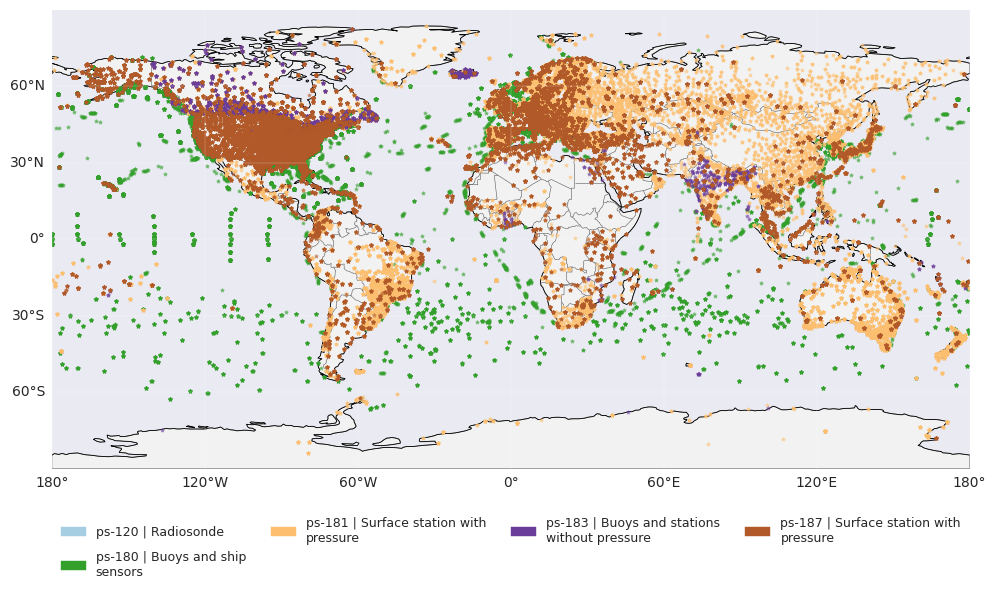

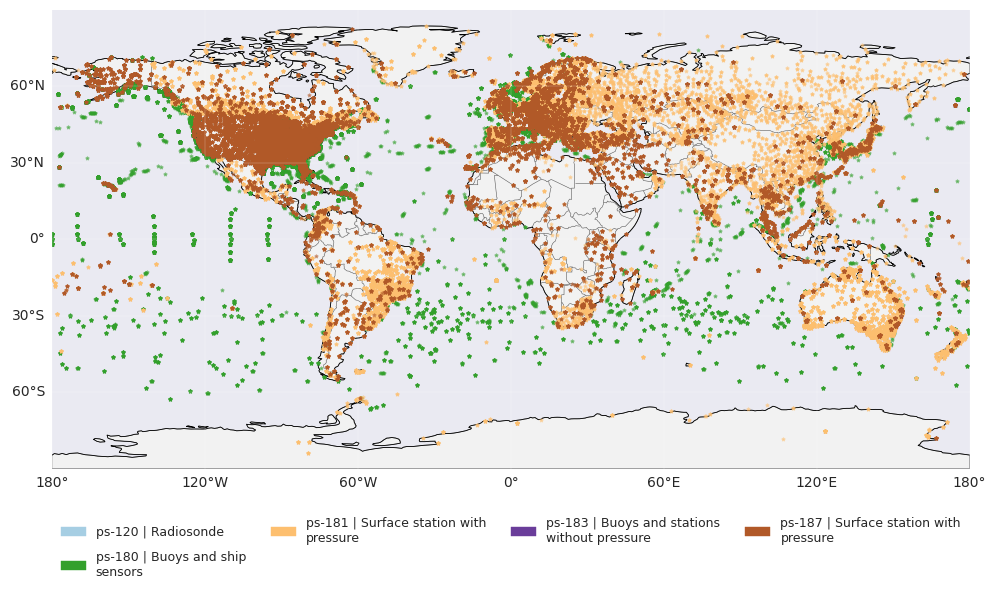

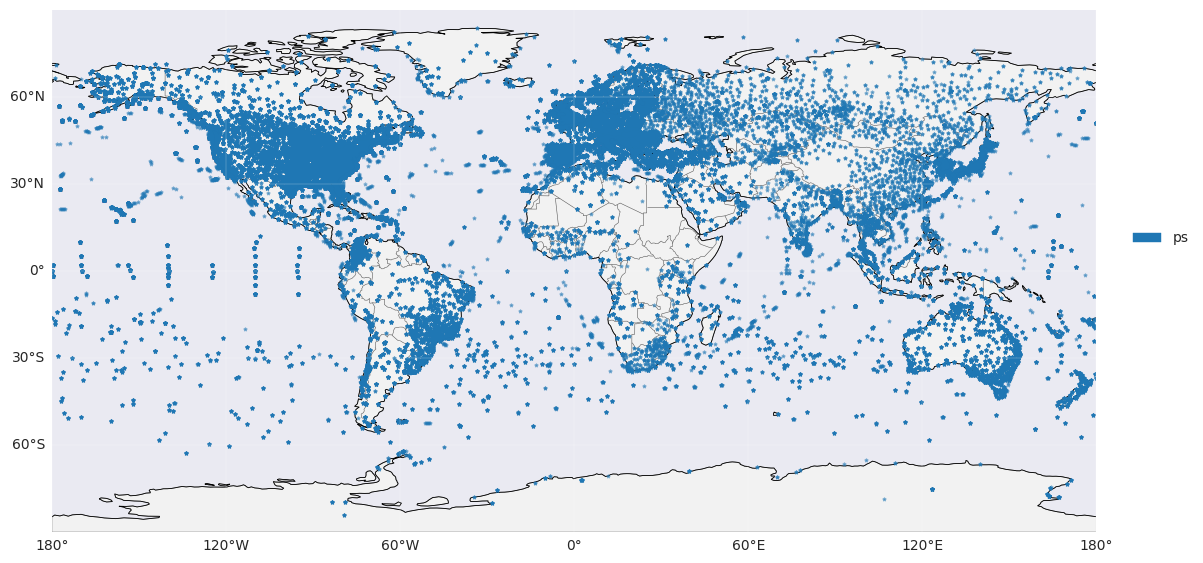

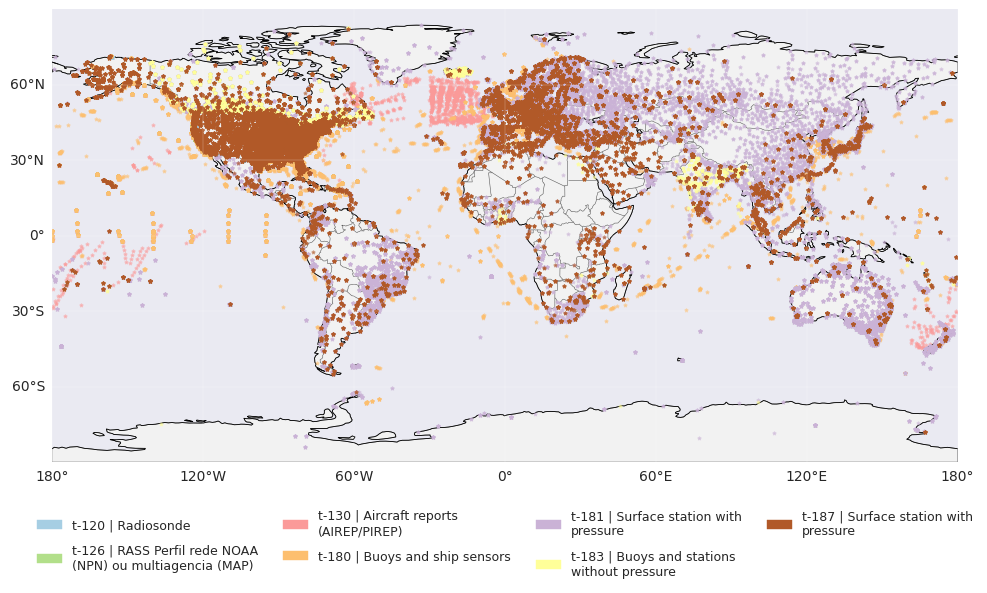

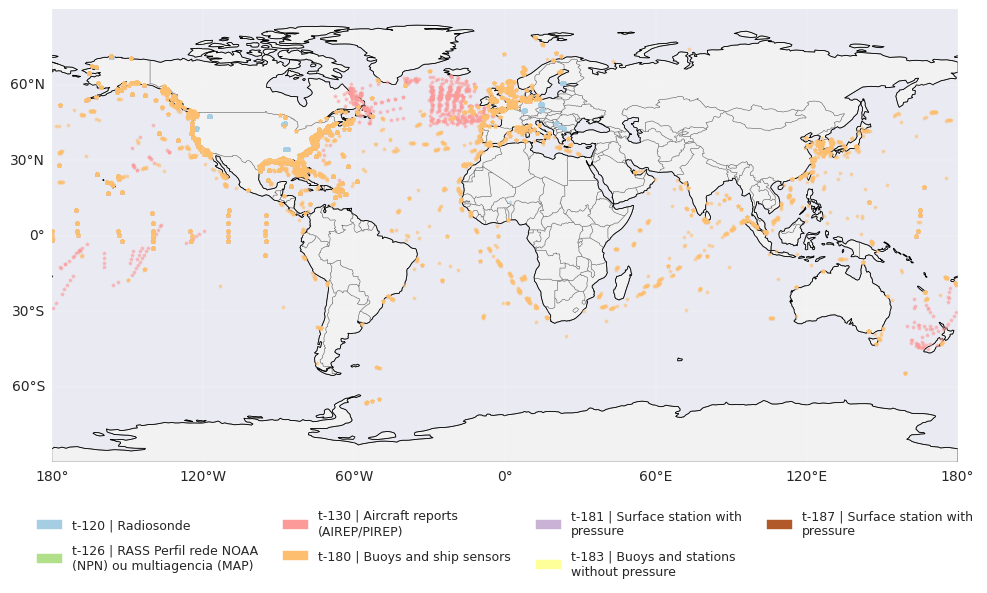

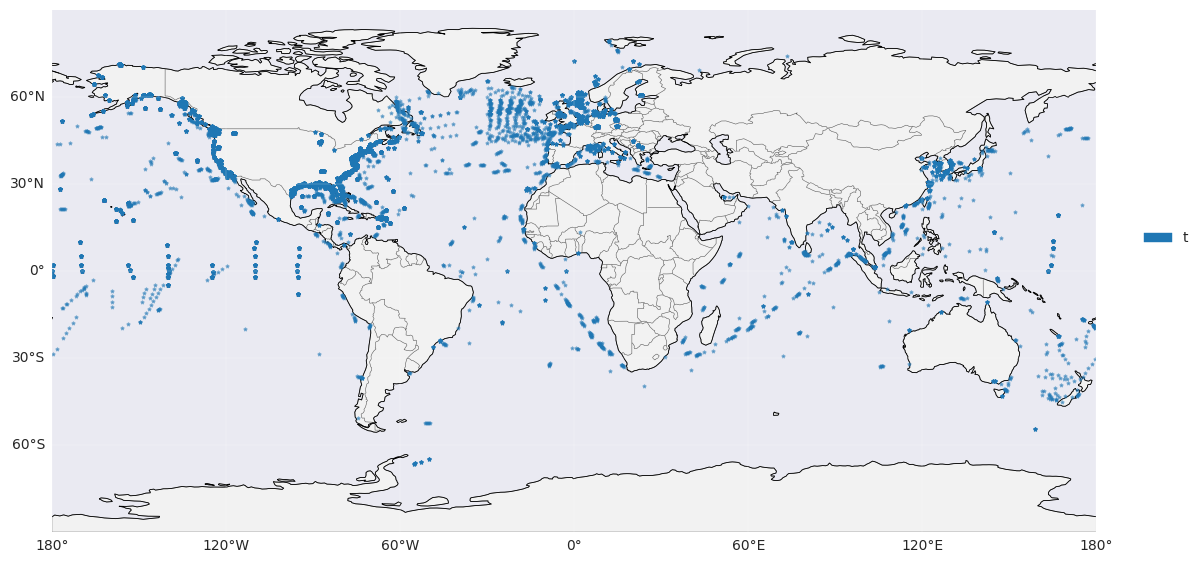

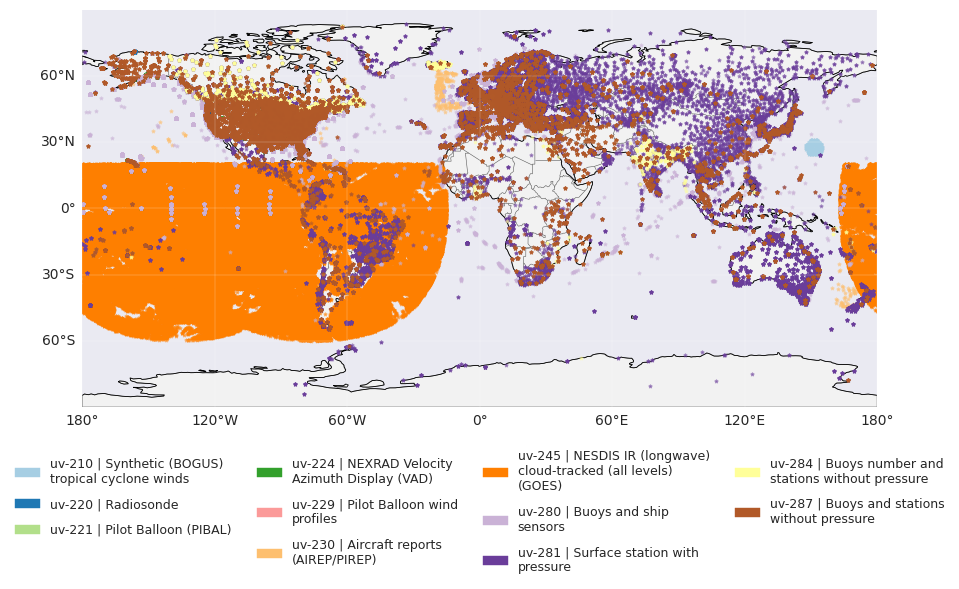

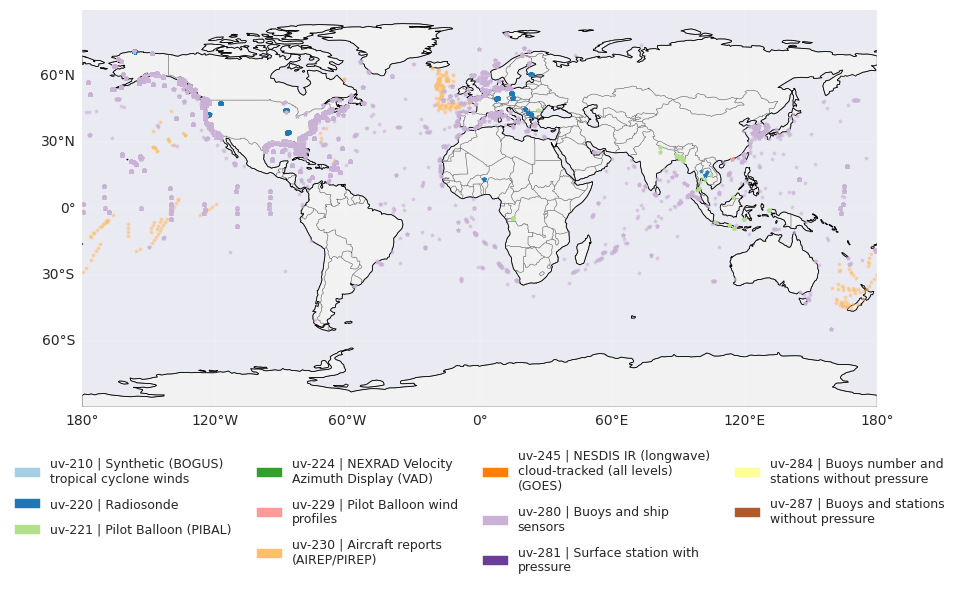

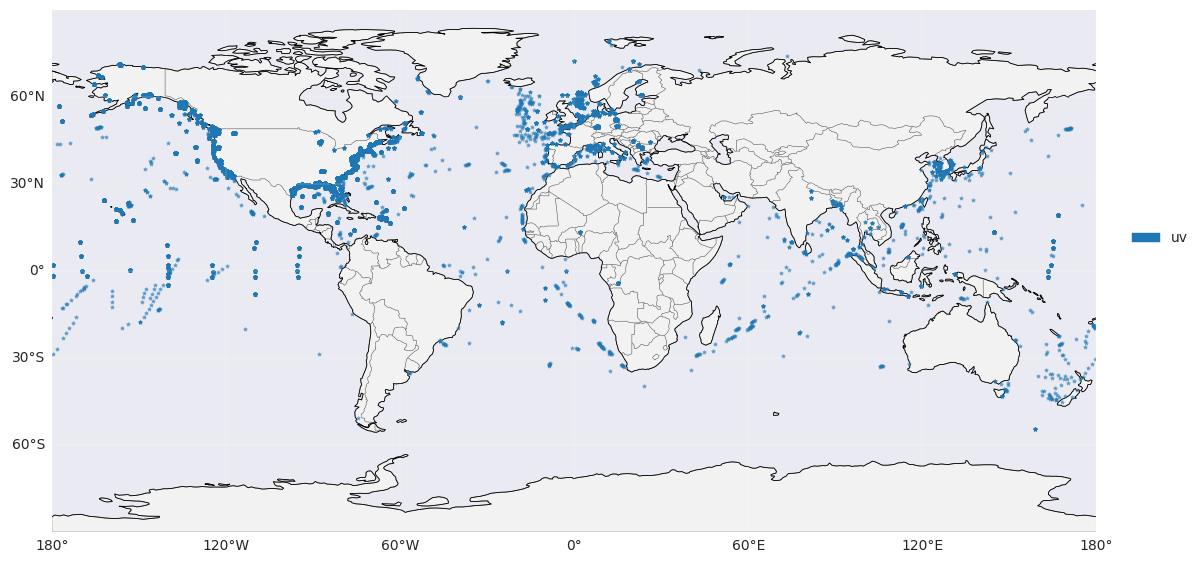

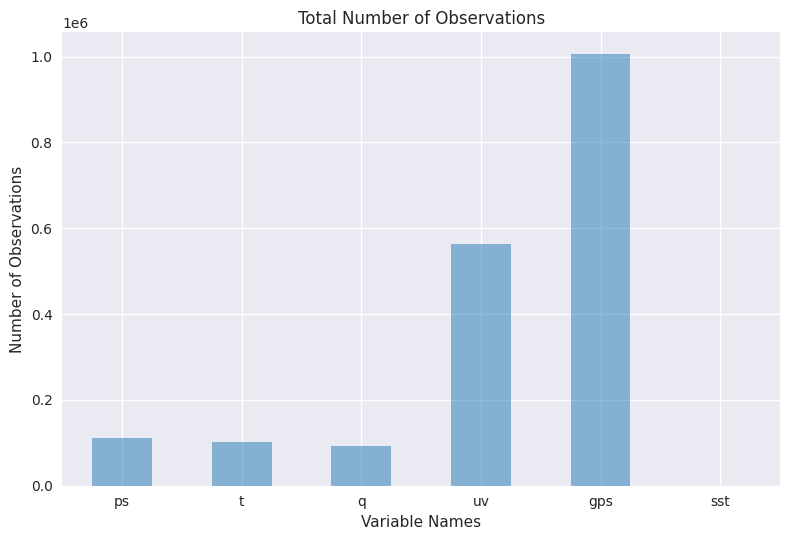

In [8]:
# varNames = ['ps','t','q','uv','gps','sst']
varNames = ['ps','t','uv']
# varNames = ['uv']

for varName in varNames:
    print('varName: ', varName)
    try:
        varTypes = var_kxs[varName]
        print('varTypes: ', varTypes)
        print('')
        
        # Todas as obs da variável
        idschar = '_'.join([str(item) for item in varTypes])
        gd.plot_diag.ptmap(gdf_list[tidx], varName=varName, varType=varTypes)
        figname = varName + '_' + idschar + '_' + 'ptmap.png'
        plt.tight_layout()
        plt.savefig(figname)
        
        # Todas as obs assimiladas da variável classificada por tipo
        idschar = '_'.join([str(item) for item in varTypes])
        gd.plot_diag.ptmap(gdf_list[tidx], varName=varName, varType=varTypes, mask='iusev==1')
        figname = varName + '_' + idschar + '_' + 'ptmap_ASS.png'
        plt.tight_layout()
        plt.savefig(figname)
        
        # Todas as obs assimiladas sem classificar por tipo
        varNames = [varName]
        idschar = '_'.join([str(item) for item in varNames])
        gd.plot_diag.pvmap(gdf_list[tidx], varName=varNames, mask='iusev==1')
        figname = idschar + '_pvmap.png'
        plt.tight_layout()
        plt.savefig(figname)
        
    except:
        print('warning --- not kx varName ', varName)
        print('')
        

# Gráfico de barras do total de obs por variável
gd.plot_diag.vcount(gdf_list[tidx])

idschar = 'All_varNames'
figname = idschar + '_vcount.png'

plt.tight_layout()
plt.savefig(figname)

In [ ]:
varNames = ['uv']

# var_uv = [220, 221, 224, 230, 232, 280, 281, 284, 287] #[210, 220, 221, 224, 230, 232, 280, 281, 284, 287] # rodada BGFE

# var_uv = [220, 221, 224, 229, 230, 280, 281, 284, 287] # NCEP -> controle

var_uv = [220, 230, 280, 281, 284]


for varName in varNames:
    print('varName: ', varName)
    try:
        varTypes = var_uv
        print('varTypes: ', varTypes)
        print('')
        
        # Todas as obs da variável
        idschar = '_'.join([str(item) for item in varTypes])
        gd.plot_diag.ptmap(gdf_list[tidx], varName=varName, varType=varTypes)
        figname = varName + '_' + idschar + '_' + 'ptmap.png'
        plt.tight_layout()
        plt.savefig(figname)
        
        # Todas as obs assimiladas da variável classificada por tipo
        idschar = '_'.join([str(item) for item in varTypes])
        gd.plot_diag.ptmap(gdf_list[tidx], varName=varName, varType=varTypes, mask='iusev==1')
        figname = varName + '_' + idschar + '_' + 'ptmap_ASS.png'
        plt.tight_layout()
        plt.savefig(figname)
        
        # Todas as obs assimiladas
        varNames = [varName]
        idschar = '_'.join([str(item) for item in varNames])
        gd.plot_diag.pvmap(gdf_list[tidx], varName=varNames, mask='iusev==1')
        figname = idschar + '_pvmap.png'
        plt.tight_layout()
        plt.savefig(figname)
        
    except:
        print('warning --- not kx varName ', varName)
        print('')
        

# # Gráfico de barras do total de obs por variável
# gd.plot_diag.vcount(gdf_list[tidx])

# idschar = 'All_varNames'
# figname = idschar + '_vcount.png'

# plt.tight_layout()
# plt.savefig(figname)

In [ ]:
varNames = ['uv']
# var_uv = [247, 246, 245, 240] # vento GOES
var_uv = [254, 253, 252, 250, 245, 246, 247] # vento GOES

for varName in varNames:
    print('varName: ', varName)
    try:
        varTypes = var_uv
        print('varTypes: ', varTypes)
        print('')
        
        # Todas as obs da variável
        idschar = '_'.join([str(item) for item in varTypes])
        gd.plot_diag.ptmap(gdf_list[tidx], varName=varName, varType=varTypes)
        figname = varName + '_' + idschar + '_' + 'ptmap.png'
        plt.tight_layout()
        plt.savefig(figname)
        
        # Todas as obs assimiladas da variável classificada por tipo
        idschar = '_'.join([str(item) for item in varTypes])
        gd.plot_diag.ptmap(gdf_list[tidx], varName=varName, varType=varTypes, mask='iusev==1')
        figname = varName + '_' + idschar + '_' + 'ptmap_ASS.png'
        plt.tight_layout()
        plt.savefig(figname)
        
        # Todas as obs assimiladas
        varNames = [varName]
        idschar = '_'.join([str(item) for item in varNames])
        gd.plot_diag.pvmap(gdf_list[tidx], varName=varNames, mask='iusev==1')
        figname = idschar + '_pvmap.png'
        plt.tight_layout()
        plt.savefig(figname)
        
    except:
        print('warning --- not kx varName ', varName)
        print('')

varName:  t
varTypes:  [180, 181, 183, 187]

varType [180, 181, 183, 187]


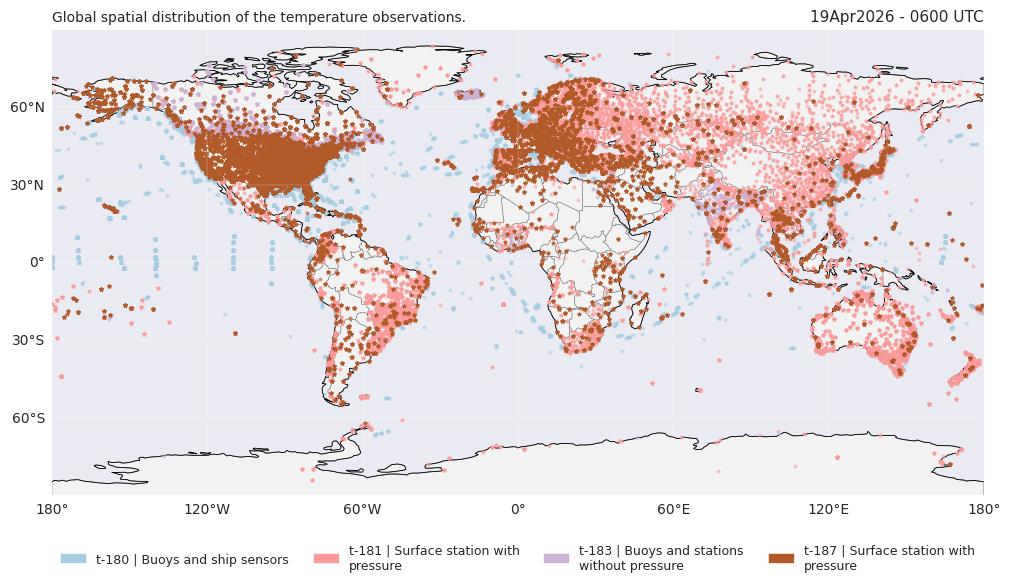

In [10]:
varNames = ['t']
# var_uv = [247, 246, 245, 240] # vento GOES
# var_uv = [253, 254, 252, 250, 245, 246, 247, 242, 243]# 240, 244]#, 255, 260] # vento GOES

#var_uv = [253, 254, 243, 252, 250, 242, 245, 246, 247]

var_uv = [180, 181, 183, 187]

# instrument_title = 'Global spatial distribution of AMV wind vectors from geostationary satellites.'

instrument_title = 'Global spatial distribution of the temperature observations.'

for varName in varNames:
    print('varName: ', varName)
    try:
        varTypes = var_uv
        print('varTypes: ', varTypes)
        print('')
        
        # Todas as obs da variável
        idschar = '_'.join([str(item) for item in varTypes])
        ax = gd.plot_diag.ptmap(gdf_list[tidx], varName=varName, varType=varTypes)
        figname = varName + '_' + idschar + '_' + 'ptmapNew.png'
        plt.tight_layout()
        plt.savefig(figname)
        
#         # Todas as obs assimiladas da variável classificada por tipo
#         idschar = '_'.join([str(item) for item in varTypes])
#         gd.plot_diag.ptmap(gdf_list[tidx], varName=varName, varType=varTypes, mask='iusev==1')
#         figname = varName + '_' + idschar + '_' + 'ptmap_ASS.png'
#         plt.tight_layout()
#         plt.savefig(figname)
        
#         # Todas as obs assimiladas
#         varNames = [varName]
#         idschar = '_'.join([str(item) for item in varNames])
#         gd.plot_diag.pvmap(gdf_list[tidx], varName=varNames, mask='iuse==1')
#         figname = idschar + '_pvmap.png'
#         plt.tight_layout()
#         plt.savefig(figname)
        
    except:
        print('warning --- not kx varName ', varName)
        print('')
        
# ###################################### NEW ########################################################
if ax != None:
    datefmt = dates[tidx]#.strftime("%Y%m%d%H")
    date = datetime.strptime(str(datefmt), "%Y%m%d%H")
    date_title = str(date.strftime("%d%b%Y - %H%M")) + ' UTC'
    plt.title(date_title, loc='right', fontsize=11)
    plt.title(instrument_title, loc='left', fontsize=10)
    #plt.annotate(forplot +' - '+ forplot2, xy=(1.02, 0.5), xytext=(0, 0), xycoords='axes fraction', 
    #             textcoords='offset points', color='gray', fontweight='bold', fontsize='10', 
    #             horizontalalignment='left', verticalalignment='center', rotation=90)
    #plt.annotate(forplot2, xy=(1.005, 0.885), xytext=(0, 0), xycoords='axes fraction', textcoords='offset points', 
     #        color='gray', fontweight='bold', fontsize='10',horizontalalignment='left', verticalalignment='center')
    
    # Obter os handles (elementos gráficos) e labels atuais
    #handles, labels = ax.gca().get_legend_handles_labels()
    # Ou definir uma nova lista de labels na ordem correta
    #novos_labels = ['Curva A', 'Curva Z'] # Ordem correta dos handles plotados acima

    # Chamar legend novamente com handles e novos labels
    #ax.legend(handles, novos_labels)
# #################################################################################################

figname = varName + '_' + idschar + '_' + 'ptmapNew.png'
plt.tight_layout()
plt.savefig(figname)
plt.show()

In [ ]:
varName = 't'
varTypes = [181]

# Todas as obs da variável
idschar = '_'.join([str(item) for item in varTypes])
gd.plot_diag.ptmap(gdf_list[tidx], varName=varName, varType=varTypes)
figname = varName + '_' + idschar + '_' + 'ptmap.png'
plt.tight_layout()
plt.savefig(figname)

Gerando uma figura com diferentes variáveis, considerando a máscara `iuse==1`:

In [ ]:
varNames = ['t'] #['uv','ps','t']
idschar = '_'.join([str(item) for item in varNames])

gd.plot_diag.pvmap(gdf_list[tidx], varName=varNames, mask='iuse==0')

figname = idschar + '_pvmap.png'

plt.tight_layout()
plt.savefig(figname)


assi =  0 moni =  1 reje =  1

antes area

após area

após gridlineas

após text lat lon


/home/radiancia/readDiagGerd-fix/src/gsidiag/legacy_api/plot.py:2731: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ax = df.plot(ax=ax,legend=True, marker=mk, color=cl, **kwargs)
/home/radiancia/readDiagGerd-fix/src/gsidiag/legacy_api/plot.py:2731: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ax = df.plot(ax=ax,legend=True, marker=mk, color=cl, **kwargs)


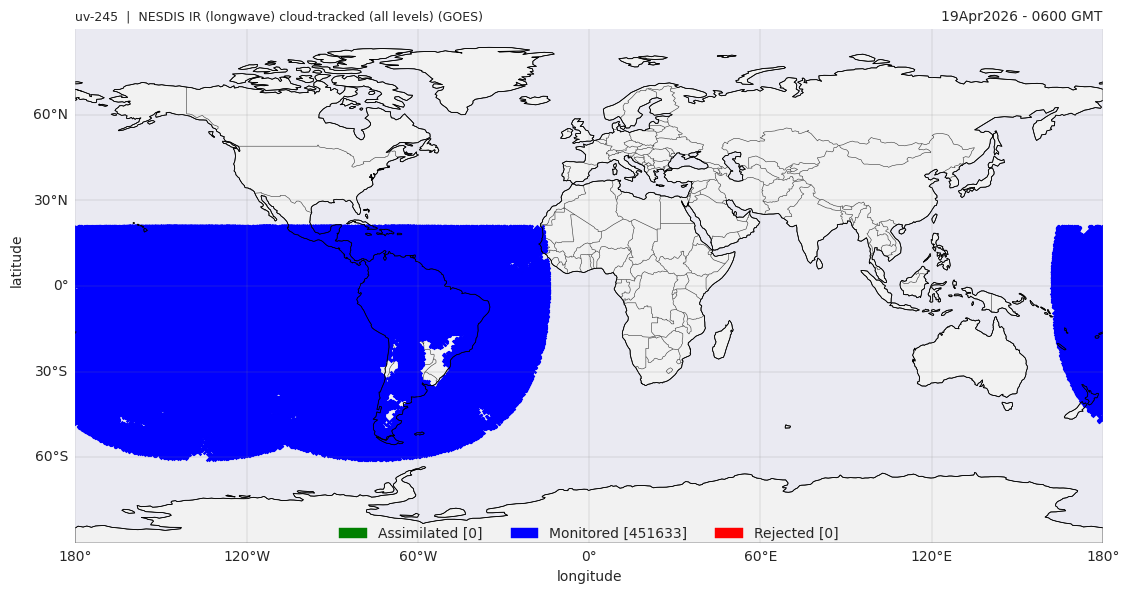

<Figure size 600x400 with 0 Axes>

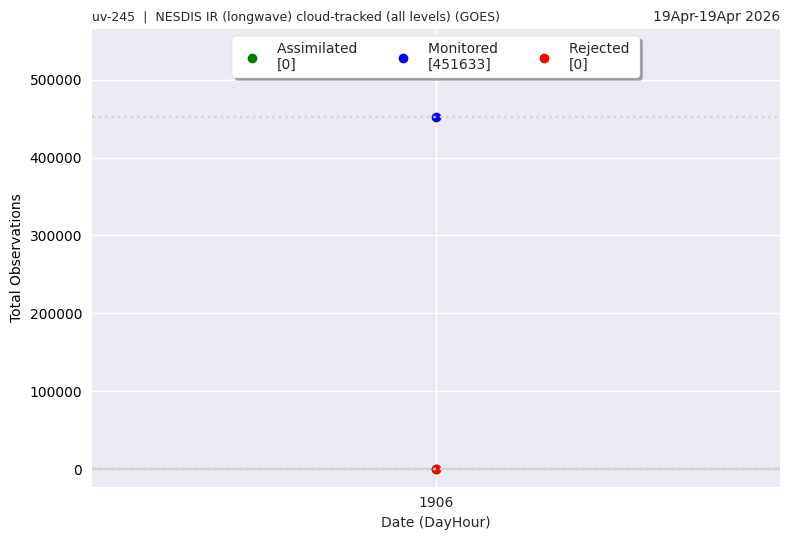

In [11]:
# varName = 'ps'
# varType = 183 #181

varName = 'uv'
varType = 245 #181

# Statcount do readDiag versão do GAD (Old pois o João fez um rotina completamente diferente que não está funcionando)
gd.plot_diag.statcount_Old(gdf_list, 
                        varName=varName, 
                        varType=varType, 
                        noiqc=True, 
                        dateIni=dateIni, 
                        dateFin=dateFin, 
                        nHour=nHour, 
                        channel=None, 
                        figTS=True, 
                        figMap=True, 
                        markersize=30.80)

Variable Name : ps
              └── kx => 120  180  181  183  187  

Variable Name : t
              └── kx => 120  126  130  180  181  183  187  

Variable Name : q
              └── kx => 120  180  181  183  187  

Variable Name : uv
              └── kx => 210  220  221  224  229  230  245  280  281  284  287  

Variable Name : gps
              └── kx => 3  5  42  43  44  66  267  269  750  751  753  754  755  825  

Variable Name : sst
              └── kx => 181  183  187  

columns ['lat', 'lon', 'elev', 'prs', 'hgt', 'time', 'iuse', 'iusev', 'wpbqc', 'inp_err', 'adj_err', 'obs', 'omf', 'kx', 'ksub', 'iqc', 'qc_setup', 'analysis_use', 'rwgt', 'errinv_inp', 'errinv_adj', 'errinv_fin', 'omf_wob', 'spread', 'dhgt', 'pbqc', 'emark', 'end_err', 'geometry', 'oma']

Formato da matriz gerada (Latitudes, Longitudes): (45, 90)



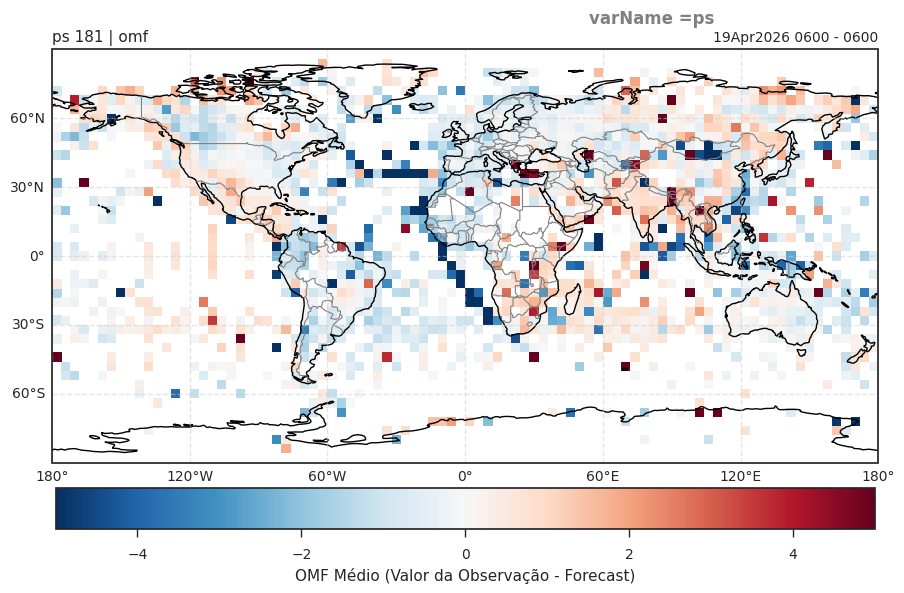

In [18]:
ax = None

import numpy as np
import pandas as pd
from scipy.stats import binned_statistic_2d

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#mask=f"((iuse == 1) & (lat>-60.0 and lat<15) & (lon>260.0 and lon<350))"
#mask=f"((lat>-60.0 and lat<15) & (lon>260.0 and lon<350))"
# mask = f"((iuse == 1) & (nchan == 3))" #None
mask = None
#mask = f"((nchan == 13))"
# mask = f"((iusev == 1))"

#mask = f"((950<=prs<=1050))"

# mask = "((-90 <= lat <= -80) & (240 <= lon <= 300))"

param = 'omf'
varName = 'ps' #'uv'
varType = 181


# 1. Definição da malha de retângulos (Resolução da grade)
resolucao = 4.0  # Tamanho do retângulo em graus (ex: 1° x 1°)

lon_bins = np.arange(0, 360 + resolucao, resolucao)
lat_bins = np.arange(-90, 90 + resolucao, resolucao)

# 2. Configuração correta da figura e do eixo com projeção Cartopy
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})

tidx = 0
df = []
gdf_list[tidx].pfileinfo()
gdf_list[tidx].obsInfo
#df = gdf_list[tidx].obsInfo
df = gdf_list[tidx].obsInfo[varName] #.loc[varType]
col = df.columns.tolist()
print('columns', col)


df_aux = []
if mask is None:
    df_aux = df
    del(df)
else:
    df_aux = df.query(mask)
    del(df)


# 3. Cálculo do valor médio de OMF em cada retângulo
# 'statistic="mean"' calcula a média. Pontos fora da malha são ignorados.
estatistica, lon_arestas, lat_arestas, binnumber = binned_statistic_2d(
    x=df_aux['lon'],
    y=df_aux['lat'],
    values=df_aux[param],
    statistic='mean',
    bins=[lon_bins, lat_bins]
)

# 4. Organização do resultado em formato de matriz
# Transposta (T) necessária para alinhar o shape [Lat, Lon] padrão de mapas
matriz_media = estatistica.T

# Substitui retângulos sem nenhuma observação (NaN) por zero
matriz_limpa = np.nan_to_num(matriz_media, nan=0.0)

print('')
print(f"Formato da matriz gerada (Latitudes, Longitudes): {matriz_limpa.shape}")
print('')



# 5. Plotagem da matriz de OMF médio 
pcm = ax.pcolormesh(
    lon_bins, 
    lat_bins, 
    matriz_media,  #matriz_oma_media.T,
    cmap='RdBu_r',       
    vmin=-5.0,           
    vmax=5.0,            
    transform=ccrs.PlateCarree()
)


# 6. Adição de elementos geográficos (linhas de costa e estados)
ax.add_feature(cfeature.COASTLINE, linestyle='-', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.8, edgecolor='gray')
# ax.add_feature(cfeature.STATES, linestyle='--', linewidth=0.5, edgecolor='gray')

# 7. Configuração das linhas de grade e rótulos de Lat/Lon
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# 8. Barra de cores (Colorbar)
cbar = plt.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cbar.set_label('OMF Médio (Valor da Observação - Forecast)')

#plt.title('Distribuição Espacial do OMF Médio por Retângulo', fontsize=14, pad=15)
#plt.show()

forplot = 'varName ='+ str(varName)
instrument_title = str(varName) + " " + str(varType) + " | " + str(param)

            
if ax != None:
    datefmt1 = dates[0]
    datefmt2 = dates[-1]
    date1 = datetime.strptime(str(datefmt1), "%Y%m%d%H")
    date2 = datetime.strptime(str(datefmt2), "%Y%m%d%H")
    #date_title = str(date1.strftime("%d%b%Y %H%M")) + ' - ' + str(date2.strftime("%d%b%Y %H%M")) #+ ' GMT'
    date_title = str(date1.strftime("%d%b%Y %H%M")) + ' - ' + str(date2.strftime("%H%M")) #+ ' GMT'
    #ax.annotate(date_title, xy=(0.75, 1.015), xytext=(0, 0), xycoords='axes fraction', textcoords='offset points', 
    #           fontsize=10, horizontalalignment='left', verticalalignment='center')
    plt.title(date_title, loc='right', fontsize=10)
    plt.title(instrument_title, loc='left', fontsize=11)
    ax.annotate(forplot, xy=(0.65, 1.075), xytext=(0, 0), xycoords='axes fraction', textcoords='offset points', 
                color='gray', fontweight='bold', fontsize='12',horizontalalignment='left', verticalalignment='center')

    #figname=varName+"_"+str(varType)+"_"+param+"_"+"CH"+str(channel)+"_"+"SulAmerica_dates_ALL"+"_"+"plot.png"
    #figname=varName+"_"+str(varType)+"_"+param+"_"+"CH"+str(channel)+"_"+"Melissa_dates_ALL"+"_"+"plot.png"
    #figname=varName+"_"+str(varType)+"_"+param+"_"+"CH"+str(channel)+"_"+"word_dates_ALL"+"_"+"plot.png"
    figname=varName+"_"+str(varType)+"_"+param+"_"+"word_dates_ALL"+"_"+"plot.png"
    plt.tight_layout()
    plt.savefig(figname)
    
plt.show()


In [ ]:
ax = None

import numpy as np
import pandas as pd
from scipy.stats import binned_statistic_2d

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#mask=f"((iuse == 1) & (lat>-60.0 and lat<15) & (lon>260.0 and lon<350))"
#mask=f"((lat>-60.0 and lat<15) & (lon>260.0 and lon<350))"
# mask = f"((iuse == 1) & (nchan == 3))" #None
mask = None
#mask = f"((nchan == 13))"
# mask = f"((iusev == 1))"


param = 'omf'
varName = 'ps' #'uv'
varType = 181

# 1. Configuração correta da figura e do eixo com projeção Cartopy
# fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})

tidx = 0
df = []
gdf_list[tidx].pfileinfo()
gdf_list[tidx].obsInfo
#df = gdf_list[tidx].obsInfo
df = gdf_list[tidx].obsInfo[varName].loc[varType]
col = df.columns.tolist()
print('columns', col)

# df = df.query('(-63 <= lat <= -61) & (295 < lon <= 300)')

# df = df.query('(-90 <= lat <= -70) & (240 < lon <= 300)')


df = df.query('(-90 <= lat <= -80) & (240 <= lon <= 300)')
# df = df.query('(-71.4 <= lat <= -71.3) & (240 < lon <= 300)')
# df = df.query('(950 <= prs <= 1050)')

# df = df.query('(991 <= prs <= 993)')

df
# df[param]

# df_data = []
# df_data.append(float(df[param].mean()))
# df_data




### Histograma

Utilize a função `pcount()` da classe `plot_diag` para obter um histograma com a contagem do número de observações para uma determinada variável:

In [ ]:
varName = 'uv'

idschar = '_'.join(str(varName))

gd.plot_diag.pcount(gdf_list[tidx], varName)

figname = idschar + '_pcount.png'

plt.tight_layout()
plt.savefig(figname)

Utilize a função `vcount()` da classe `plot_diag` para obter um histograma com a contagem do número de observações para todos os tipos de variáveis:

In [ ]:
gd.plot_diag.vcount(gdf_list[tidx])

idschar = 'All_varNames'
figname = idschar + '_vcount.png'

plt.tight_layout()
plt.savefig(figname)

De forma semelhante, utilize a função `kxcount()` da classe `plot_diag` para obter um histograma com a contagem do número de observações por tipo:

In [ ]:
gd.plot_diag.kxcount(gdf_list[tidx])

### Série temporal

<a id='time_series'></a>
A seguir são apresentadas as opções de figuras com a função `time_series()`, incluída na classe `plot_diag`. Inicialmente é gerada uma figura com os parâmetros já fixados nesta seção. Em seguida são apresentadas figuras alterando os parâmetros `Level`, `Lay` e `SingleL`.

Plotando uma série temporal do OmA e OmF:

In [ ]:
varName = 'uv'
varType = 245
gd.plot_diag.time_series(gdf_list,
                         varName=varName, 
                         varType=varType,
                         mask='iusev==1',
                         dateIni=dateIni, 
                         dateFin=dateFin, 
                         nHour=nHour, 
                         vminOMA=vminOMA, 
                         vmaxOMA=vmaxOMA, 
                         vminSTD=vminSTD, 
                         vmaxSTD=vmaxSTD, 
                         Level=Level, 
                         Lay=Lay, 
                         SingleL=SingleL,
                         Clean=False)

No caso anterior, o parâmetro `Level` estava fixo em 1000 hPa com `SingleL` igual a `All`, ou seja, toda a atmosfera foi considerada como uma única camada e o valor 1000 hPa funciona apenas como uma flag para indicar que não existe variação em altura. Ainda com `Level=1000`, pode-se usar `SingleL='OneL'` para uma única camada em torno do valor de `Level`, neste caso 1000 hPa, variando entre `Level-Lay` e `Level+Lay` (na definição de variáveis, `Lay` foi fixado com 15 hPa; no caso de ser `None`, o valor padrão de 50 hPa é utilizado).

In [ ]:
SingleL = 'OneL'
Lay = 15

gd.plot_diag.time_series(gdf_list,
                         varName=varName, 
                         varType=varType,
                         mask='iuse==0',
                         dateIni=dateIni, 
                         dateFin=dateFin, 
                         nHour=nHour, 
                         vminOMA=vminOMA, 
                         vmaxOMA=vmaxOMA, 
                         vminSTD=vminSTD, 
                         vmaxSTD=vmaxSTD, 
                         Level=Level, 
                         Lay=Lay, 
                         SingleL=SingleL,
                         Clean=False)

Observe como no exemplo acima a quantidade de dados diminui, uma vez que agora está sendo utilizada uma camada entre 1015 e 985 hPa.

Agora vamos alterar para não fixar em um único nível ou camada, ou seja, altear a variável `Level` para `None` ou `Zlevs`. A opção `None` busca os dados em cada nível existente nos arquivos e faz a figura para todos esses níveis, porém os valores no eixo y (ordenada) são apenas dos níveis padrão. É importante esclarecer que os chamados níveis padrão estão definidos na classe `read_diag` e podem ser acessados utilizando o método `zlevs` da seguinte forma:

In [ ]:
gdf_list[tidx].zlevs

Dessa forma, pode-se utilizar o parâmetro `Level='Zlevs'` para produzir uma série temporal por níveis:

In [ ]:
Level = 'Zlevs'
Lay = 15

gd.plot_diag.time_series(gdf_list,
                         varName=varName, 
                         varType=varType,
                         mask='iuse==0',
                         dateIni=dateIni, 
                         dateFin=dateFin, 
                         nHour=nHour, 
                         vminOMA=vminOMA, 
                         vmaxOMA=vmaxOMA, 
                         vminSTD=vminSTD, 
                         vmaxSTD=vmaxSTD, 
                         Level=Level, 
                         Lay=Lay, 
                         SingleL=SingleL,
                         Clean=False)

Se `Lay=None`, então as camadas são preenchidas variando entre o valor médio considerando as camadas inferiores e superiores. Por exemplo, para o nível de 700 hPa é construída uma camada entre 750 e 650 hPa, uma vez que os níveis inferiores e superiores são 800 e 600 hPa, respectivamente. Para o nível de 1000 hPa a camada varia entre 1050 e 950 hPa.

O mesmo exemplo anterior, mas considerando `Level='Zlevs'`:

In [ ]:
Level = 'Zlevs'
Lay = None

gd.plot_diag.time_series(gdf_list,
                         varName=varName, 
                         varType=varType,
                         mask='iuse==0',
                         dateIni=dateIni, 
                         dateFin=dateFin, 
                         nHour=nHour, 
                         vminOMA=vminOMA, 
                         vmaxOMA=vmaxOMA, 
                         vminSTD=vminSTD, 
                         vmaxSTD=vmaxSTD, 
                         Level=Level, 
                         Lay=Lay, 
                         SingleL=SingleL,
                         Clean=False)

Finalmente, existe a opção de se considerar todos os níveis, ou seja, `Level=None`. Esta opção traz certa dificuldade na visualização da informação na figura por conta da grande quantidade de níveis e distribuição dos dados em todos os níveis:

In [ ]:
Level = None

gd.plot_diag.time_series(gdf_list,
                         varName=varName, 
                         varType=varType,
                         mask='iuse==0',
                         dateIni=dateIni, 
                         dateFin=dateFin, 
                         nHour=nHour, 
                         vminOMA=vminOMA, 
                         vmaxOMA=vmaxOMA, 
                         vminSTD=vminSTD, 
                         vmaxSTD=vmaxSTD, 
                         Level=Level, 
                         Lay=Lay, 
                         SingleL=SingleL,
                         Clean=False)

Finalizado o uso dos arquivos, feche-os para liberar a memória utilizada:

In [ ]:
for file in gdf_list:
    file.close()

O `readDiag` é um pacote em desenvolvimento e em constante atualização. Novas funcionalidades serão adicionadas e demonstradas por meio deste notebook.